In [1]:
import os

from td3.config.app_config import AppConfig
from td3.data.data_processor import DataProcessor
from td3.metrics.metrics import ExperimentMetrics
from td3.utils.date_utils import check_if_later_date
from td3.utils.file_utils import create_experiment_directories, RunType
from td3.utils.graph_utils import plot_multi_line_chart, plot_episode_weights

EXPERIMENT_DIR = "simulations/train/run_2026-02-12_16-38-39/"

def load_config() -> AppConfig:
    config_path = os.path.join(EXPERIMENT_DIR, "config.json")
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found at {config_path}")
    return AppConfig.from_json(config_path)

In [ ]:
def export_weights():
    pass

In [2]:
def get_model_paths():
    names = []
    paths = []
    for filename in os.listdir(EXPERIMENT_DIR + "models"):
        if filename.endswith(".pth"):
            names.append(filename)
            paths.append(os.path.join(EXPERIMENT_DIR + "models", filename))
    return names, paths

In [3]:
train_config = load_config()
model_names, model_paths = get_model_paths()

experiment_metrics = ExperimentMetrics()
experiment_dir, plots_dir, models_dir, weights_dir = create_experiment_directories(run_type=RunType.TEST)

app_config = AppConfig(
    start_date="2019-01-21",
    end_date="2023-01-01",
    learning_start_episode=None,
    number_of_episodes=1,
    filter_in=[]
)

check_if_later_date(app_config.start_date, train_config.end_date)

Device chosen: cpu


In [4]:
dp = DataProcessor(data_dir=app_config.data_dir)
df = dp.load_panel(
    tickers=app_config.ticker_config.tickers,
    start=app_config.start_date,
    end=app_config.end_date,
)

df_features = df.drop(columns=app_config.filter_out, level=1)
dates = df_features.index.unique().to_list()
df_prices = df.loc[:, (slice(None), ['close'])]
data_3d_features, _, tickers, features = dp.to_3d(df_features)
data_3d_prices, _, _, _ = dp.to_3d(df_prices)

Loaded frames: 10
After concat: (2243, 340)
After start filter: (1525, 340)
After end filter: (995, 340)
Final panel: (995, 340)


In [5]:
from td3.models.td3 import TD3
from td3.environment.portfolio import PortfolioEnv

for model_path in model_paths:
    env = PortfolioEnv(features=data_3d_features,prices=data_3d_prices,
        tickers=tickers,app_config=app_config)

    td3_agent = TD3(hidden_size=app_config.hidden_size, device=app_config.device,
        state_dim=int(env.observation_space.shape[0]), action_dim=env.action_space.shape[0],
        noise_anneal_episodes=app_config.number_of_episodes, learning_starts=app_config.learning_start_episode)
    td3_agent.load_model(model_path)

    state = env.reset()
    done = False

    run_metrics = experiment_metrics.start_run(model_path)
    while True:
        step_metrics = run_metrics.start_step()
        if done:
            break

        action, noisy_logits = td3_agent.select_action(state, 1, None, None, False)
        new_state, reward_val, done, trunc, info = env.step(action)
        state = new_state

        total_reward = (run_metrics.episodes[-2].reward if len(run_metrics.episodes) > 1 else 0.0)  + float(reward_val)
        step_metrics.set_basic(total_reward,env.portfolio_value.curr,action)

steps: 995, assets: 10, feature_dim: 28


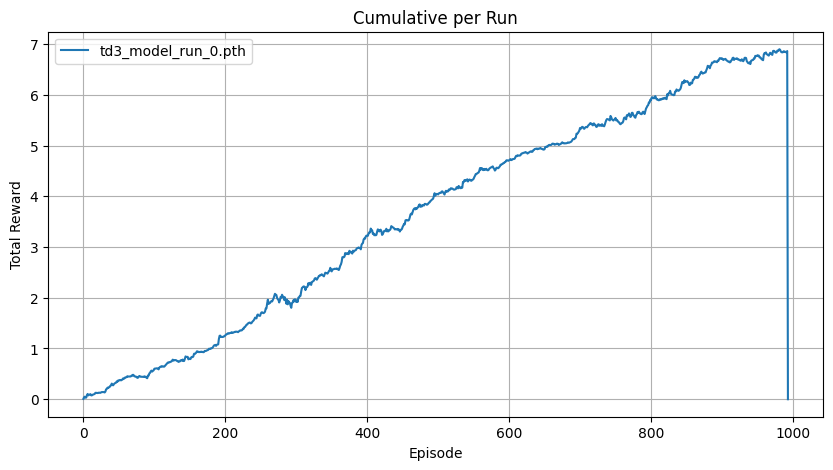

In [6]:
plot_multi_line_chart(
    data_series=[
        [step.reward for step in run.episodes]
        for run in experiment_metrics.runs
    ],
    labels=model_names,
    title="Cumulative per Run",
    image_name="episode_rewards.png",
    save_dir=plots_dir,
    y_label="Total Reward"
)

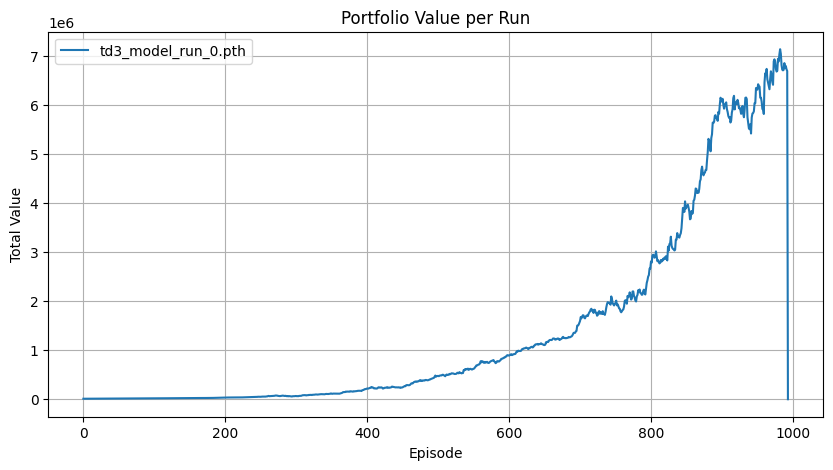

In [7]:
plot_multi_line_chart(
    data_series=[
        [step.portfolio_value for step in run.episodes]
        for run in experiment_metrics.runs
    ],
    labels=model_names,
    title="Portfolio Value per Run",
    image_name="portfolio_reward.png",
    save_dir=plots_dir,
    y_label="Total Value"
)

In [8]:
tickers = app_config.ticker_config.tickers_with_cash
N = len(tickers)

for i, run in enumerate(experiment_metrics.runs):
    all_weights = [ep.weights for ep in run.episodes if ep.weights is not None]
    print(plots_dir)
    plot_episode_weights(
        all_weights=all_weights,
        episode=run.run_id,
        tickers=tickers,
        title="Action Weights per Run",
        save_dir=plots_dir,
        filename=f"weights_run_{i}.jpg",
    )

simulations/test/run_2026-02-12_18-25-45/plots
